# MITGCM kinetic Energy Analysis at mooring locations 

**Purpose**: Code for preforming the kinetic energy analysis at mooring locations. I will compute FKE using spectral methods at each of the mooring locations. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2
import matplotlib.colors as mcolors

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, detrend, compute_amp_phase

Set data analysis parameters

In [3]:
# Set processing parameters
option_filter = 'total'    # Options: 'total', 'baroclinic', 'barotropic'

# Set time and space parameters
dt           = 1*(60)*(60)               # No binning: 1 hour resolution   
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/mooring_locations/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files

In [4]:
# Obtain filename paths
filename_u = PATH + "UVEL_CCS4_hrly_ts_profile.nc"
filename_v = PATH + "VVEL_CCS4_hrly_ts_profile.nc"

# Generate the nc data structure
nc_u = Dataset(filename_u, 'r')
nc_v = Dataset(filename_v, 'r')

# Extract data variables
site   = nc_u['site'][:]
depth  = nc_u.variables['Z'][:]
lon    = nc_u.variables['XC'][:]
lat    = nc_u.variables['YC'][:]
time   =  num2date(nc_u.variables['time'][:], nc_u.variables['time'].units)

u_raw  = nc_u.variables['UVEL'][:]
v_raw  = nc_v.variables['VVEL'][:]

# Mask data at fill values (zero for the MITgcm output)
u_m = np.ma.masked_where(u_raw == 0, u_raw)
v_m = np.ma.masked_where(v_raw == 0, v_raw)

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Compute the kinetic energy spectrum by taking the fourier transform of the velocity components ($E_u(f) = \lvert \hat u(f)\rvert^2$ and $E_v(f) = \lvert \hat v(f)\rvert^2$) and summing them together: 

$$
E_{KE}(f) = \frac{1}{2}(E_u + E_v)
$$

Note that this avoids spectral contamination that occurs if we were to talk the fourier transform of kinetic energy (a squared quantity). Additionally, compute the fraction of kinetic energy explained by frequencies greater than 1 week: 

$$
FKE = \frac{\int_{f_c}^{f_n} E_{KE}(f) \,df}{\sigma^2}
$$

where the cutoff frequency is $f_c = 1/7$ cpd, the nyquist frequency is $f_n$ and $\sigma^2$ is the total variance of the anomaly time series (with the annual and semi-annual cycle removed).  

In [5]:
# Set parameters
w1, w2        = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
segment_years = 1 
overlap       = 0.5

# Obtain a example segment 
segments_u = segment_time_series(time_dt, u_m[0,:,0], segment_years=segment_years, overlap=overlap)
segments_v = segment_time_series(time_dt, v_m[0,:,0], segment_years=segment_years, overlap=overlap)

# Set dimensions     
nseg,ntime  = np.shape(segments_u)[0], np.shape(segments_u)[2]
nsite,_,ndepth = np.shape(u_m)

# Set autocorrelation parameters
lag       = ntime
norm      = 0
estimator = 'biased'
T_days = dt*(1/60)*(1/60)*(1/24)

# Set spectral parameters
M = 10                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 
f_cut = 1/7                                                  # Cutoff frequency for FVE calculation units: cpd

# Define frequency range for slope fitting 
fmin_sub = 3*10**(-2) 
fmax_sub = 8*10**(-1) 
fmin_sup = 1 
fmax_sup = 12

# Convert to seconds since start time
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Initialize arrays 
S_seg           = np.zeros((nsite,ndepth,nfft))
Su_seg          = np.zeros((nsite,ndepth,nfft))
Sv_seg          = np.zeros((nsite,ndepth,nfft))
CI_seg          = np.zeros((nsite,ndepth,nfft,2))
CI_u_seg        = np.zeros((nsite,ndepth,nfft,2))
CI_v_seg        = np.zeros((nsite,ndepth,nfft,2))
var_anomaly     = np.zeros((nsite,ndepth))
fve_seg         = np.zeros((nsite,ndepth))

# Loop through distance offshore 
for isite in range(0,nsite):
    
    # Set progress bar
    progress = (isite) / (nsite)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Loop through depth
    for idepth in range(0,ndepth):
        
        # Initialize the ith time series 
        u_ts = u_m[isite,:,idepth]
        v_ts = v_m[isite,:,idepth]

        if option_filter == 'baroclinic':
            # Remove the barotropic component (i.e., depth-averaged velocity) from the time series
            u_ts = u_ts - np.nanmean(u_m[isite,:,:], axis=1)
            v_ts = v_ts - np.nanmean(v_m[isite,:,:], axis=1)

        # Skip depth if all values are masked
        if np.all(u_ts.mask) | np.all(v_ts.mask):
            continue

        # Remove annual and semi-annual cycle 
        hfit, x_data, x_data_sigma, _ = unweighted_lsf(u_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
        u_ts_rm = u_ts - hfit

        hfit, x_data, x_data_sigma, _ = unweighted_lsf(v_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
        v_ts_rm = v_ts - hfit

        # Segment the time series 
        segments_u = segment_time_series(time_dt, u_ts_rm, segment_years=segment_years, overlap=overlap)
        segments_v = segment_time_series(time_dt, v_ts_rm, segment_years=segment_years, overlap=overlap)

        # Initialize arrays
        Su_seg_tmp      = np.full((nseg,nfft), np.nan)
        Sv_seg_tmp      = np.full((nseg,nfft), np.nan)
        CI_u_seg_tmp    = np.zeros((nseg,nfft,2))
        CI_v_seg_tmp    = np.zeros((nseg,nfft,2))
        CI_ccw_tmp      = np.zeros((nseg,nfft,2))
        CI_cw_tmp       = np.zeros((nseg,nfft,2))
        var_u_seg_anom  = np.zeros((nseg,1))
        var_v_seg_anom  = np.zeros((nseg,1))
        var_seg_anom    = np.zeros((nseg,1))

        # Loop through segments
        for i, ((tseg_u, useg), (tseg_v, vseg)) in enumerate(zip(segments_u, segments_v)):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg_u[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg_u])
            
            # Detrend both components
            u_dt = detrend(useg, time_elapsed_seg, mean=0)
            v_dt = detrend(vseg, time_elapsed_seg, mean=0)

            # Compute frequency power spectrum
            Su_seg_tmp[i,:], f_seg, CI_u_seg_tmp[i,:], _ = spectrum1D_frequency(u_dt, dt, M, units)
            Sv_seg_tmp[i,:], _,     CI_v_seg_tmp[i,:], _ = spectrum1D_frequency(v_dt, dt, M, units)

            # Compute the variance of the ith segment 
            var_u_seg_anom[i] = np.var(u_dt, ddof=1)
            var_v_seg_anom[i] = np.var(v_dt, ddof=1)

            # Compute the total variance of the segment (i.e., sum of the variance of the two components)
            var_seg_anom[i] = 1/2 * (var_u_seg_anom[i] + var_v_seg_anom[i])

        # Compute the mean variance between segments and its uncertainty 
        var_anomaly[isite,idepth]     = np.mean(var_seg_anom)

        # Compute the mean frequency spectrum and convert to cycles per day
        Su_seg[isite,idepth,:] = np.nanmean(Su_seg_tmp, axis=0)/(60 * 60 * 24)
        Sv_seg[isite,idepth,:] = np.nanmean(Sv_seg_tmp, axis=0)/(60 * 60 * 24)

        # Compute the mean frequency spectrum of the kinetic energy 
        S_seg[isite,idepth,:]  = 1/2 * (Su_seg[isite,idepth,:] + Sv_seg[isite,idepth,:])
        f_cpd_seg = f_seg*(60*60*24)

        # Set significance level and effective degrees of freedom 
        alpha      = 0.05                         # Significance level
        nu         = (36 / 19) * (2 * ntime - 1)  # Number of degrees of freedom for each spectral estimate
        nu_eff     = 2 * nu                       # Number of effective degrees of freedom for the average spectrum with 50% overlap between the window (if full independent: nu_eff = 3*nu, if full dependent (rho = 1): nu_eff = nu. So the 50% case lies inbetween). 
        
        # Compute the upper and lower bounds of confidence interval
        error_high = nu_eff / chi2.ppf(alpha / 2, nu_eff)    
        error_low  = nu_eff / chi2.ppf(1 - alpha / 2, nu_eff)

        # Compute the 95% confidence level for the average spectrum
        CI_u_seg[isite,idepth,:,:] = np.column_stack((error_low * Su_seg[isite,idepth,:], error_high * Su_seg[isite,idepth,:]))
        CI_v_seg[isite,idepth,:,:] = np.column_stack((error_low * Sv_seg[isite,idepth,:], error_high * Sv_seg[isite,idepth,:]))

        #-------------------------------------# 
        # Compute the fraction of variance explained by the high-frequency variability 
        #-------------------------------------# 
        
        # Create frequency mask for high and low frequency bands
        mask_low  = f_cpd_seg <= f_cut
        mask_high = ~mask_low

        # Compute frequency spacing (IMPORTANT)
        df = np.gradient(f_cpd_seg)

        # Apply masks and integrate over frequency axis
        var_high_m = np.sum(S_seg[isite,idepth,:] * mask_high * df)

        # Compute the fraction of variance explained by the high-frequency variability 
        fve_seg[isite,idepth] = var_high_m/var_anomaly[isite,idepth]


Progress: 66.7%

Mask fill values

In [6]:
fve_seg = np.ma.masked_where(fve_seg == 0, fve_seg)
S_seg = np.ma.masked_where(S_seg == 0, S_seg)

Plot the FKE 

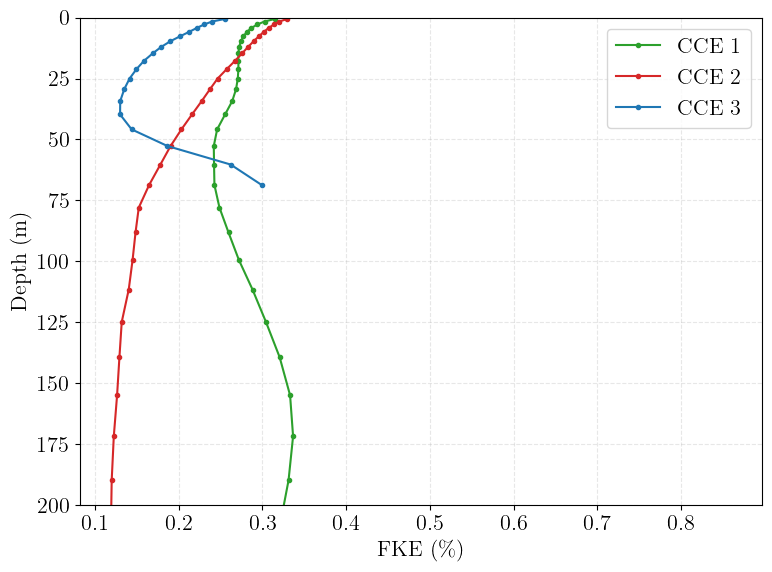

In [7]:
# Create figure
fig,ax = plt.subplots(1,1,figsize=(8, 6))

# Plot mean profiles for each mooring
ax.plot(fve_seg[0,:],abs(depth),'.-',color='tab:green',label='CCE 1')
ax.plot(fve_seg[1,:],abs(depth),'.-',color='tab:red',label='CCE 2')
ax.plot(fve_seg[2,:],abs(depth),'.-',color='tab:blue',label='CCE 3')

# Set axis attributes
ax.set_xlabel(r'FKE ($\%$)')
ax.set_ylabel("Depth (m)")
ax.set_ylim([0,200])
ax.invert_yaxis()
ax.legend()
ax.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

Plot the kinetic energy spectrogram

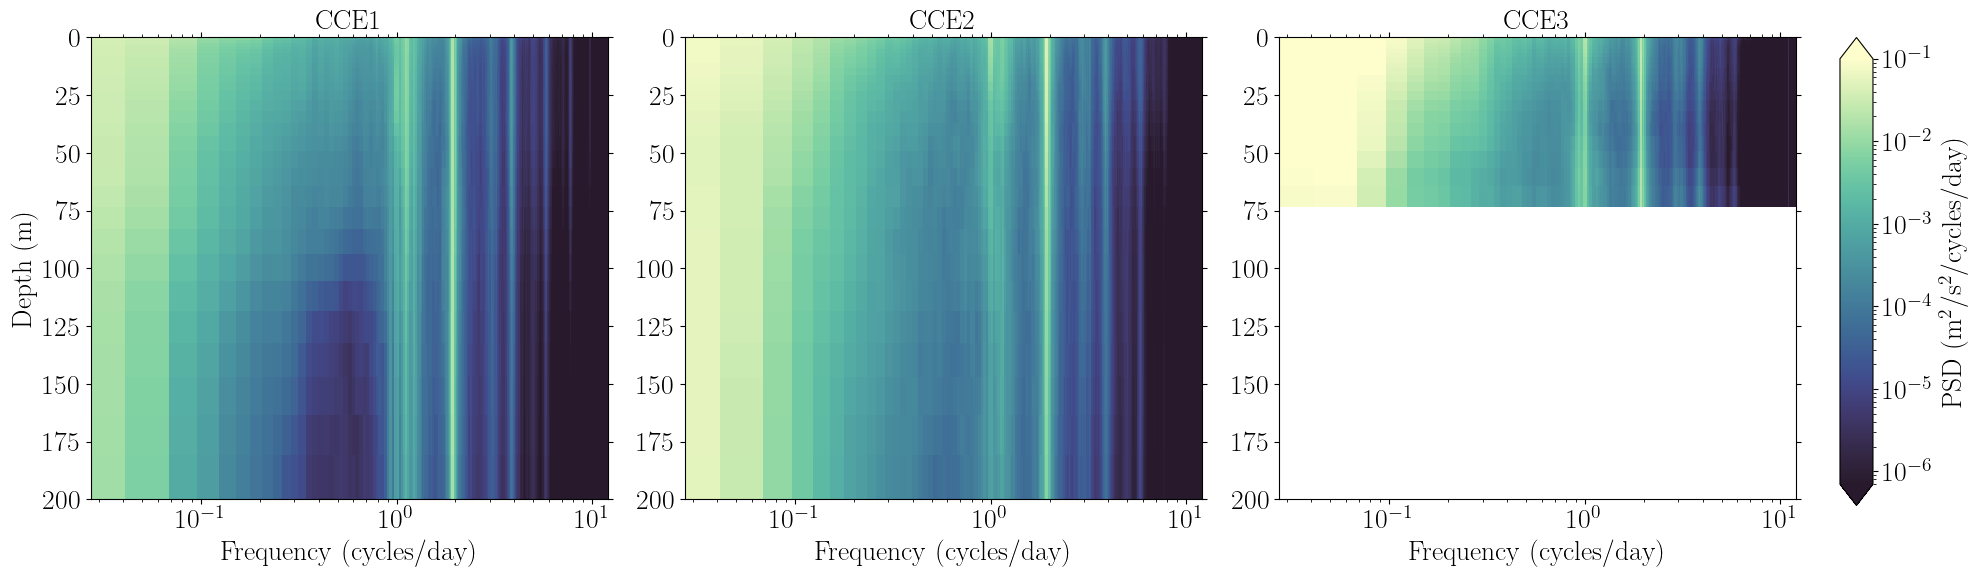

In [8]:
# Set colormap and levels
cmap = cmo.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=1e-1) #mcolors.LogNorm(vmin=7e-7, vmax=2e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_seg, abs(depth))

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(22, 6))
ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 kinetic energy spectrogram 
pc = ax1.pcolormesh(F_m,D_m,S_seg[0,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax1.set_title('CCE1', fontsize=fontsize)
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax1.set_ylim(0,200)
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

# Plot CCE2 kinetic energy spectrogram 
pc = ax2.pcolormesh(F_m,D_m,S_seg[1,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax2.set_title('CCE2', fontsize=fontsize)
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax2.set_ylim(0,200)
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE3 kinetic energy spectrogram
pc = ax3.pcolormesh(F_m,D_m,S_seg[2,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax3.set_title('CCE3', fontsize=fontsize)
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax3.set_ylim(0,200)
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (m$^2$/s$^2$/cycles/day)')

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.15)
plt.show()

Save data in a npz file 

In [9]:
# Check if file exists, then delete it
if option_filter == 'baroclinic':
    file_KE_path = PATH + "mitgcm_cce_mooring_ke_baroclinic.npz"
else: 
    file_KE_path = PATH + "mitgcm_cce_mooring_ke.npz"
if os.path.exists(file_KE_path):
    os.remove(file_KE_path)

# Set metadata
metadata = {
    'description': 'Kinetic energy depth spectrogram and fraction of Kinetic energy explained by high frequency variability greater than 1 week at the three CCE mooring locations.',
    'source': 'MITgcm model output',
    'coordinates units': '1 hr'
}
    
# Save data arrays and metadata to a .npz file
np.savez(file_KE_path,
    S_ke              = S_seg,
    S_u               = Su_seg,
    S_v               = Sv_seg,
    CI_ke              = CI_seg,
    CI_u              = CI_u_seg,
    CI_v              = CI_v_seg,
    FKE               = fve_seg,
    var_anom          = var_anomaly,
    lon               = lon,
    lat               = lat,
    depth             = depth,
    f_cpd             = f_cpd_seg,
    metadata          = metadata
    )